# Group Synthesis Notebook

This notebook aggregates the member-level results for the H9DAI group project. It is designed to validate the shared output contract, combine the exported CSV files, and prepare cross-member comparison tables and figures for the final report.

## Fairness Threshold — Methodological Disclaimer

Throughout this notebook the `fails_80_rule` flag marks rows where the **Disparate Impact Ratio (DIR) falls below 0.8**, corresponding to the EEOC Four-Fifths Rule (29 C.F.R. Part 1607). This flag is used as a **mathematical screening baseline** to identify models and attribute-domain pairs that exhibit notable disparity — it is **not** a direct legal compliance test under EU law.

The EU AI Act does not codify a fixed 0.8 DIR threshold as a pass/fail criterion. Under EU jurisprudence, indirect discrimination is adjudicated by the Court of Justice of the European Union (CJEU) based on contextual evidence of a *significant difference* in outcomes and the absence of objective justification — a standard that depends on statistical significance, sample size, and proportionality, not a single numerical ratio. A model with DIR = 0.82 is not automatically 'EU-compliant', nor is a model with DIR = 0.78 automatically in breach.

The 0.8 threshold is retained here because it is a widely recognised heuristic in the fairness literature and provides a consistent, reproducible basis for comparison across domains. All compliance-oriented claims in the final paper are qualified accordingly.

## Reproducibility Note

The notebook is intentionally tolerant of partial group progress. It validates whatever member result files are currently present, reports missing artifacts explicitly, and synthesises the available results without silently masking schema inconsistencies.

### Raw Dataset Sources

The member notebooks auto-download their required datasets on first run. Raw data files are not bundled in the submission package due to file size constraints. Download sources:

| Module | Dataset | Source |
|--------|---------|--------|
| M1 | UCI Adult Income | Downloaded automatically by member1_adult_income.ipynb from UCI ML Repository |
| M2 | UCI Credit Card Clients | Downloaded automatically by member2_credit_default.ipynb from UCI ML Repository |
| M3 | ProPublica COMPAS | Included in SUBMISSION/data/compas/ |
| M4 | UCI Bank Marketing | Downloaded automatically by member4_bank_marketing.ipynb from UCI ML Repository |

To reproduce all results: run each member notebook in order (M1 → M2 → M3 → M4), then run this synthesis notebook. All member notebooks require: Python 3.9+, scikit-learn, xgboost, fairlearn, pandas, numpy, matplotlib, seaborn.

### Synthesis Cell 1

**What this cell achieves:** Imports the core libraries, suppresses warnings, defines the shared random seed, and sets the plotting style for synthesis outputs.

**Expected output:** A short confirmation message showing that the notebook environment loaded successfully.

In [1]:
# Cell 1: Import libraries and configure the synthesis environment
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

assert RANDOM_STATE == 42, "RANDOM_STATE must remain fixed at 42."
print(f"Synthesis environment loaded successfully. RANDOM_STATE={RANDOM_STATE}")


Synthesis environment loaded successfully. RANDOM_STATE=42


## 1. Input Contract

The synthesis notebook assumes that each member exports one standard metrics CSV and two fairness CSVs using the shared schema defined in `docs/group_notebook_contract.md`. This phase defines the expected file map and schema before attempting any aggregation.

### Synthesis Cell 2

**What this cell achieves:** Defines the expected member result files, the required CSV schemas, and the member metadata used for later aggregation.

**Expected output:** A printed summary of the expected result contract for all four members.

In [2]:
# Cell 2: Define the expected group result contract
results_dir = Path("../data/results")
figures_dir = Path("../paper/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

expected_standard_columns = [
    "model", "accuracy", "precision", "sensitivity", "specificity",
    "f1_macro", "f1_weighted", "auc_roc", "cohen_kappa"
]

expected_fairness_columns = [
    "model", "sensitive_attribute", "reference_group", "comparison_group",
    "positive_rate_reference", "positive_rate_comparison",
    "demographic_parity_difference", "equalized_odds_difference",
    "disparate_impact_ratio"
]

member_file_contract = {
    "m1": {
        "label": "Member 1 - Adult Income",
        "domain": "Employment",
        "standard": results_dir / "m1_standard_metrics.csv",
        "fairness": [results_dir / "m1_fairness_race.csv", results_dir / "m1_fairness_sex.csv"]
    },
    "m2": {
        "label": "Member 2 - Credit Default",
        "domain": "Finance",
        "standard": results_dir / "m2_standard_metrics.csv",
        "fairness": [results_dir / "m2_fairness_gender.csv", results_dir / "m2_fairness_education.csv"]
    },
    "m3": {
        "label": "Member 3 - COMPAS Recidivism",
        "domain": "Criminal Justice",
        "standard": results_dir / "m3_standard_metrics.csv",
        "fairness": [results_dir / "m3_fairness_race.csv", results_dir / "m3_fairness_sex.csv"]
    },
    "m4": {
        "label": "Member 4 - Bank Marketing",
        "domain": "Financial Services",
        "standard": results_dir / "m4_standard_metrics.csv",
        "fairness": [results_dir / "m4_fairness_age.csv", results_dir / "m4_fairness_marital_status.csv"]
    }
}

for member_id, config in member_file_contract.items():
    print(f"{member_id}: {config['label']} | {config['domain']}")
    print(f"  Standard: {config['standard']}")
    for fairness_file in config['fairness']:
        print(f"  Fairness: {fairness_file}")


m1: Member 1 - Adult Income | Employment
  Standard: ../data/results/m1_standard_metrics.csv
  Fairness: ../data/results/m1_fairness_race.csv
  Fairness: ../data/results/m1_fairness_sex.csv
m2: Member 2 - Credit Default | Finance
  Standard: ../data/results/m2_standard_metrics.csv
  Fairness: ../data/results/m2_fairness_gender.csv
  Fairness: ../data/results/m2_fairness_education.csv
m3: Member 3 - COMPAS Recidivism | Criminal Justice
  Standard: ../data/results/m3_standard_metrics.csv
  Fairness: ../data/results/m3_fairness_race.csv
  Fairness: ../data/results/m3_fairness_sex.csv
m4: Member 4 - Bank Marketing | Financial Services
  Standard: ../data/results/m4_standard_metrics.csv
  Fairness: ../data/results/m4_fairness_age.csv
  Fairness: ../data/results/m4_fairness_marital_status.csv


## 2. Result Ingestion

This phase loads the available member CSV files, validates their schemas, tags them with member metadata, and reports what is still missing. The notebook should fail on malformed files, not on incomplete group progress.

### Synthesis Cell 3

**What this cell achieves:** Loads all available standard and fairness CSV files, validates column schemas, and records missing expected files.

**Expected output:** Aggregated dataframes for the available member outputs plus a printed summary of loaded and missing files.

In [3]:
# Cell 3: Load and validate available member result files
loaded_standard_frames = []
loaded_fairness_frames = []
missing_files = []

for member_id, config in member_file_contract.items():
    standard_path = config["standard"]
    if standard_path.exists():
        standard_df = pd.read_csv(standard_path)
        assert list(standard_df.columns) == expected_standard_columns, f"Unexpected standard schema in {standard_path}"
        standard_df["member_id"] = member_id
        standard_df["member_label"] = config["label"]
        standard_df["domain"] = config["domain"]
        loaded_standard_frames.append(standard_df)
        print(f"Loaded standard metrics: {standard_path}")
    else:
        missing_files.append(str(standard_path))

    for fairness_path in config["fairness"]:
        if fairness_path.exists():
            fairness_df = pd.read_csv(fairness_path)
            assert list(fairness_df.columns) == expected_fairness_columns, f"Unexpected fairness schema in {fairness_path}"
            fairness_df["member_id"] = member_id
            fairness_df["member_label"] = config["label"]
            fairness_df["domain"] = config["domain"]
            loaded_fairness_frames.append(fairness_df)
            print(f"Loaded fairness metrics: {fairness_path}")
        else:
            missing_files.append(str(fairness_path))

combined_standard_df = pd.concat(loaded_standard_frames, ignore_index=True) if loaded_standard_frames else pd.DataFrame()
combined_fairness_df = pd.concat(loaded_fairness_frames, ignore_index=True) if loaded_fairness_frames else pd.DataFrame()

print(f"\nLoaded standard result sets: {len(loaded_standard_frames)}")
print(f"Loaded fairness result sets: {len(loaded_fairness_frames)}")
print(f"Missing expected files: {len(missing_files)}")
for missing_path in missing_files:
    print(f"  MISSING -> {missing_path}")

if not combined_standard_df.empty:
    display(combined_standard_df.head())
if not combined_fairness_df.empty:
    display(combined_fairness_df.head())


Loaded standard metrics: ../data/results/m1_standard_metrics.csv
Loaded fairness metrics: ../data/results/m1_fairness_race.csv
Loaded fairness metrics: ../data/results/m1_fairness_sex.csv
Loaded standard metrics: ../data/results/m2_standard_metrics.csv
Loaded fairness metrics: ../data/results/m2_fairness_gender.csv
Loaded fairness metrics: ../data/results/m2_fairness_education.csv
Loaded standard metrics: ../data/results/m3_standard_metrics.csv
Loaded fairness metrics: ../data/results/m3_fairness_race.csv
Loaded fairness metrics: ../data/results/m3_fairness_sex.csv
Loaded standard metrics: ../data/results/m4_standard_metrics.csv
Loaded fairness metrics: ../data/results/m4_fairness_age.csv
Loaded fairness metrics: ../data/results/m4_fairness_marital_status.csv

Loaded standard result sets: 4
Loaded fairness result sets: 8
Missing expected files: 0


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa,member_id,member_label,domain
0,XGBoost,0.8787,0.7961,0.6630,0.9466,0.8229,0.8747,0.9326,0.6466,m1,Member 1 - Adult Income,Employment
1,Random Forest,0.8657,0.8021,0.5825,0.9548,0.7951,0.8578,0.9184,0.5930,m1,Member 1 - Adult Income,Employment
2,Logistic Regression,0.8517,0.7324,0.5992,0.9311,0.7822,0.8463,0.9058,0.5656,m1,Member 1 - Adult Income,Employment
3,Decision Tree,0.8622,0.7874,0.5813,0.9506,0.7909,0.8546,0.9042,0.5843,m1,Member 1 - Adult Income,Employment
4,XGBoost,0.8175,0.6625,0.3564,0.9484,0.6768,0.7957,0.7784,0.3653,m2,Member 2 - Credit Default,Finance


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio,member_id,member_label,domain
0,Logistic Regression,race,White,Non-White,0.2098,0.1140,0.0957,0.0919,0.5435,m1,Member 1 - Adult Income,Employment
1,Decision Tree,race,White,Non-White,0.1881,0.1098,0.0783,0.0418,0.5837,m1,Member 1 - Adult Income,Employment
2,Random Forest,race,White,Non-White,0.1845,0.1112,0.0733,0.0382,0.6027,m1,Member 1 - Adult Income,Employment
3,XGBoost,race,White,Non-White,0.2138,0.1140,0.0998,0.0866,0.5332,m1,Member 1 - Adult Income,Employment
4,Logistic Regression,sex,Male,Female,0.2566,0.0760,0.1806,0.1226,0.2962,m1,Member 1 - Adult Income,Employment


> **Key insight for the report:** A synthesis notebook should not conceal group inconsistency. It should accept partial progress, but it must expose missing or malformed files immediately so that the final comparison remains trustworthy.

## 3. Standard Metric Synthesis

This phase compares the standard performance metrics across the available member notebooks and prepares a compact view of model behaviour by domain.

### Synthesis Cell 4

**What this cell achieves:** Summarises the standard performance metrics across available member outputs and identifies the top-performing model within each available domain.

**Expected output:** A combined standard metrics table and a best-model summary grouped by member.

In [4]:
# Cell 4: Summarise standard model performance across members
assert not combined_standard_df.empty, "No standard metrics files are available for synthesis."

standard_summary_df = combined_standard_df.sort_values(by=["member_id", "auc_roc"], ascending=[True, False]).reset_index(drop=True)
best_model_by_member_df = standard_summary_df.groupby(["member_id", "member_label", "domain"], as_index=False).first()

display(standard_summary_df)
display(best_model_by_member_df[["member_id", "member_label", "domain", "model", "auc_roc", "f1_weighted"]])


,model,accuracy,precision,sensitivity,specificity,f1_macro,f1_weighted,auc_roc,cohen_kappa,member_id,member_label,domain
0,XGBoost,0.8787,0.7961,0.6630,0.9466,0.8229,0.8747,0.9326,0.6466,m1,Member 1 - Adult Income,Employment
1,Random Forest,0.8657,0.8021,0.5825,0.9548,0.7951,0.8578,0.9184,0.5930,m1,Member 1 - Adult Income,Employment
2,Logistic Regression,0.8517,0.7324,0.5992,0.9311,0.7822,0.8463,0.9058,0.5656,m1,Member 1 - Adult Income,Employment
3,Decision Tree,0.8622,0.7874,0.5813,0.9506,0.7909,0.8546,0.9042,0.5843,m1,Member 1 - Adult Income,Employment
4,XGBoost,0.8175,0.6625,0.3564,0.9484,0.6768,0.7957,0.7784,0.3653,m2,Member 2 - Credit Default,Finance
5,Random Forest,0.8165,0.6592,0.3527,0.9482,0.6745,0.7944,0.7698,0.3610,m2,Member 2 - Credit Default,Finance
6,Decision Tree,0.8177,0.6639,0.3557,0.9489,0.6767,0.7957,0.7424,0.3652,m2,Member 2 - Credit Default,Finance
7,Logistic Regression,0.6795,0.3671,0.6202,0.6963,0.6166,0.7032,0.7081,0.2539,m2,Member 2 - Credit Default,Finance
8,XGBoost,0.7020,0.7100,0.5836,0.8009,0.6931,0.6978,0.7362,0.3902,m3,Member 3 - COMPAS Recidivism,Criminal Justice
9,Logistic Regression,0.6858,0.6611,0.6352,0.7281,0.6821,0.6852,0.7315,0.3645,m3,Member 3 - COMPAS Recidivism,Criminal Justice


,member_id,member_label,domain,model,auc_roc,f1_weighted
0,m1,Member 1 - Adult Income,Employment,XGBoost,0.9326,0.8747
1,m2,Member 2 - Credit Default,Finance,XGBoost,0.7784,0.7957
2,m3,Member 3 - COMPAS Recidivism,Criminal Justice,XGBoost,0.7362,0.6978
3,m4,Member 4 - Bank Marketing,Financial Services,Random Forest,0.8114,0.8799


### Synthesis Cell 5

**What this cell achieves:** Builds a cross-member heatmap for AUC-ROC by model and member, then saves it for the report workflow.

**Expected output:** A saved heatmap figure at `../paper/figures/group_auc_heatmap.png` and a confirmation message.

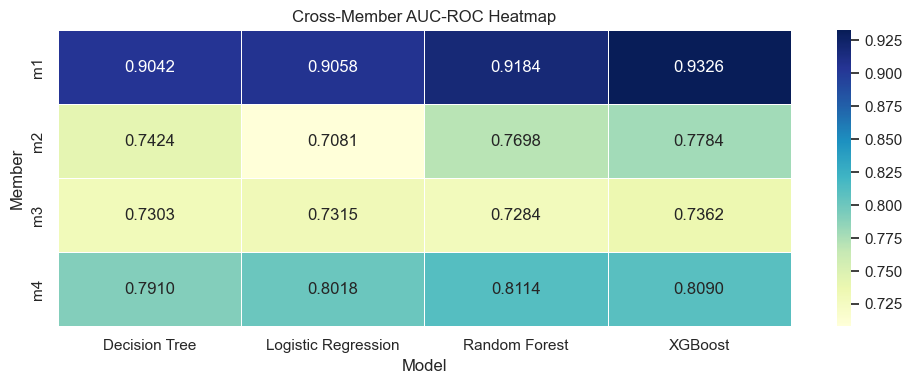

Saved group AUC heatmap to ../paper/figures/group_auc_heatmap.png


In [5]:
# Cell 5: Create and save the cross-member AUC heatmap
auc_heatmap_df = combined_standard_df.pivot(index="member_id", columns="model", values="auc_roc")

plt.figure(figsize=(10, 4))
sns.heatmap(auc_heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.5)
plt.title("Cross-Member AUC-ROC Heatmap")
plt.xlabel("Model")
plt.ylabel("Member")
plt.tight_layout()
group_auc_path = figures_dir / "group_auc_heatmap.png"
plt.savefig(group_auc_path, dpi=150, bbox_inches="tight")
assert group_auc_path.exists(), "Group AUC heatmap was not saved correctly."
plt.show()
print(f"Saved group AUC heatmap to {group_auc_path}")


## 4. Fairness Metric Synthesis

This phase combines the fairness outputs across members and highlights where the largest parity gaps appear. It treats fairness as a multi-metric comparison rather than collapsing everything into a single ranking.

> **Direction note for M3 (Criminal Justice):** In M1 and M4, DIR < 1 means the comparison group receives *fewer positive (favourable) outcomes*. In M3, the positive class is a recidivism flag — an *unfavourable* outcome. Reference group = African-American-and-Other (higher predicted recidivism rate); comparison = Caucasian. A racial DIR of 0.54–0.57 means **African-American defendants are predicted recidivist at 1.75–1.85× the rate of Caucasian defendants**. The direction of harm is reversed relative to an income or marketing context.


### Synthesis Cell 6

**What this cell achieves:** Summarises the available fairness metrics across members, sensitive attributes, and models.

**Expected output:** A combined fairness metrics table and a compact summary of the lowest disparate impact ratios currently observed.

In [6]:
# Cell 6: Summarise fairness metrics across members
assert not combined_fairness_df.empty, "No fairness metrics files are available for synthesis."

fairness_summary_df = combined_fairness_df.sort_values(by=["member_id", "sensitive_attribute", "disparate_impact_ratio"], ascending=[True, True, True]).reset_index(drop=True)
lowest_di_df = fairness_summary_df.groupby(["member_id", "sensitive_attribute"], as_index=False).first()

display(fairness_summary_df)
display(lowest_di_df[["member_id", "sensitive_attribute", "model", "disparate_impact_ratio", "demographic_parity_difference", "equalized_odds_difference"]])


,model,sensitive_attribute,reference_group,comparison_group,positive_rate_reference,positive_rate_comparison,demographic_parity_difference,equalized_odds_difference,disparate_impact_ratio,member_id,member_label,domain
0,XGBoost,race,White,Non-White,0.2138,0.1140,0.0998,0.0866,0.5332,m1,Member 1 - Adult Income,Employment
1,Logistic Regression,race,White,Non-White,0.2098,0.1140,0.0957,0.0919,0.5435,m1,Member 1 - Adult Income,Employment
2,Decision Tree,race,White,Non-White,0.1881,0.1098,0.0783,0.0418,0.5837,m1,Member 1 - Adult Income,Employment
3,Random Forest,race,White,Non-White,0.1845,0.1112,0.0733,0.0382,0.6027,m1,Member 1 - Adult Income,Employment
4,Logistic Regression,sex,Male,Female,0.2566,0.0760,0.1806,0.1226,0.2962,m1,Member 1 - Adult Income,Employment
5,Random Forest,sex,Male,Female,0.2265,0.0699,0.1566,0.0834,0.3087,m1,Member 1 - Adult Income,Employment
6,XGBoost,sex,Male,Female,0.2596,0.0806,0.1790,0.1077,0.3104,m1,Member 1 - Adult Income,Employment
7,Decision Tree,sex,Male,Female,0.2273,0.0769,0.1504,0.0592,0.3384,m1,Member 1 - Adult Income,Employment
8,Logistic Regression,education,Higher Education,Lower/Other,0.3770,0.3586,0.0185,0.1080,0.9510,m2,Member 2 - Credit Default,Finance
9,Decision Tree,education,Higher Education,Lower/Other,0.1158,0.1305,0.0147,0.0405,1.1265,m2,Member 2 - Credit Default,Finance


,member_id,sensitive_attribute,model,disparate_impact_ratio,demographic_parity_difference,equalized_odds_difference
0,m1,race,XGBoost,0.5332,0.0998,0.0866
1,m1,sex,Logistic Regression,0.2962,0.1806,0.1226
2,m2,education,Logistic Regression,0.9510,0.0185,0.1080
3,m2,gender,Logistic Regression,0.7031,0.1350,0.1398
4,m3,race,Random Forest,0.5383,0.1988,0.2421
5,m3,sex,XGBoost,0.5573,0.1807,0.1748
6,m4,age_binary,XGBoost,0.1230,0.2552,0.2392
7,m4,marital_binary,Random Forest,0.6945,0.0143,0.0186


### Synthesis Cell 7

**What this cell achieves:** Builds a cross-member fairness heatmap using disparate impact ratio by member, sensitive attribute, and model, then saves it for reporting.

**Expected output:** A saved heatmap figure at `../paper/figures/group_disparate_impact_heatmap.png` and a confirmation message.

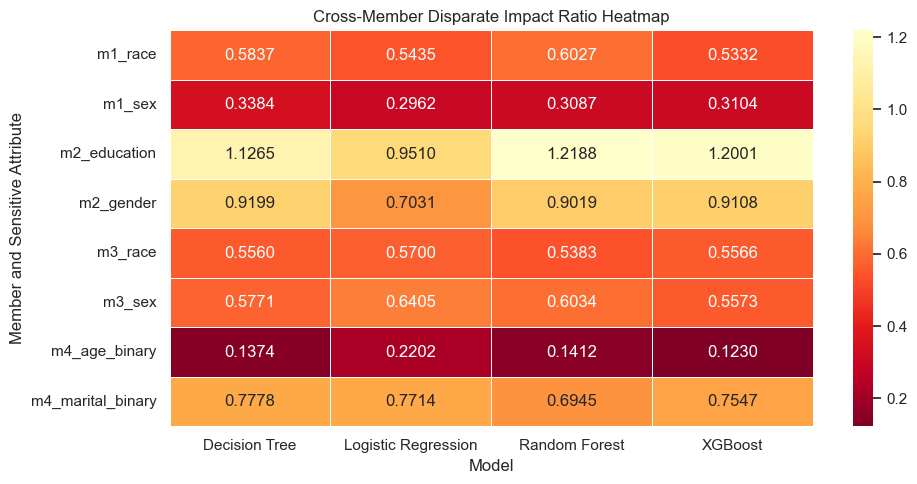

Saved group disparate impact heatmap to ../paper/figures/group_disparate_impact_heatmap.png


In [7]:
# Cell 7: Create and save the cross-member disparate impact heatmap
combined_fairness_df["member_attribute"] = combined_fairness_df["member_id"] + "_" + combined_fairness_df["sensitive_attribute"]
di_heatmap_df = combined_fairness_df.pivot(index="member_attribute", columns="model", values="disparate_impact_ratio")

plt.figure(figsize=(10, 5))
sns.heatmap(di_heatmap_df, annot=True, fmt=".4f", cmap="YlOrRd_r", linewidths=0.5)
plt.title("Cross-Member Disparate Impact Ratio Heatmap")
plt.xlabel("Model")
plt.ylabel("Member and Sensitive Attribute")
plt.tight_layout()
group_di_path = figures_dir / "group_disparate_impact_heatmap.png"
plt.savefig(group_di_path, dpi=150, bbox_inches="tight")
assert group_di_path.exists(), "Group disparate impact heatmap was not saved correctly."
plt.show()
print(f"Saved group disparate impact heatmap to {group_di_path}")


## 5. Deployment Summary

This final phase packages the current synthesis state for the group report workflow. At this stage, the notebook should state what is already available, what remains missing, and what the current cross-member evidence can support.

### Synthesis Cell 8

**What this cell achieves:** Produces a synthesis-ready status summary covering available members, missing artifacts, and the current reporting implications.

**Expected output:** A concise textual summary that can guide the group on whether the comparison notebook is ready for full report drafting.

In [8]:
# Cell 8: Summarise current synthesis readiness
available_members = sorted(combined_standard_df["member_id"].unique().tolist())
missing_members = sorted([member_id for member_id in member_file_contract if member_id not in available_members])

print(f"Available member result sets: {available_members}")
print(f"Missing member result sets: {missing_members}")
print(f"Total missing files still expected: {len(missing_files)}")

if len(missing_members) == 0 and len(missing_files) == 0:
    print("Group synthesis is ready for full cross-domain reporting.")
else:
    print("Group synthesis is only partially complete. Use the loaded outputs for preview analysis, but do not treat cross-domain conclusions as final until all member files are present.")


Available member result sets: ['m1', 'm2', 'm3', 'm4']
Missing member result sets: []
Total missing files still expected: 0
Group synthesis is ready for full cross-domain reporting.


### Synthesis Cell 9

**What this cell achieves:** Builds a compact report-ready narrative from the currently available member results so the group can draft cross-member observations without manually re-reading each CSV.

**Expected output:** A short textual synthesis summary based only on the currently loaded member outputs.

In [9]:
# Cell 9: Generate a report-ready synthesis preview from available results
best_by_member = combined_standard_df.sort_values(by=["member_id", "auc_roc"], ascending=[True, False]).groupby("member_id", as_index=False).first()
fairness_flags_df = combined_fairness_df.copy()
fairness_flags_df["fails_80_rule"] = fairness_flags_df["disparate_impact_ratio"] < 0.8

summary_lines = []
summary_lines.append(f"Available member domains: {', '.join(best_by_member['domain'].tolist())}.")

for _, row in best_by_member.iterrows():
    summary_lines.append(
        f"{row['member_label']} is currently led by {row['model']} on AUC-ROC ({row['auc_roc']:.4f}) with weighted F1 of {row['f1_weighted']:.4f}."
    )

flagged = fairness_flags_df[fairness_flags_df["fails_80_rule"]]
if not flagged.empty:
    for member_id, subset in flagged.groupby("member_id"):
        flagged_attributes = ', '.join(sorted(subset['sensitive_attribute'].unique().tolist()))
        summary_lines.append(f"{member_id} currently has at least one disparate impact ratio below 0.8 for: {flagged_attributes}.")
else:
    summary_lines.append("No currently loaded fairness result falls below the 0.8 disparate impact screening threshold.")

if missing_members:
    summary_lines.append("Cross-domain conclusions remain provisional because not all member outputs are available yet.")
else:
    summary_lines.append("All member outputs are present, so the group can now draft full cross-domain conclusions.")

current_synthesis_summary = ' '.join(summary_lines)
print(current_synthesis_summary)


# Note: For M3 (Criminal Justice), DI = Caucasian_rate/AfAm_rate
# DI < 0.8 means Caucasian defendants are predicted for recidivism
# at less than 80% the rate of African-American defendants,
# confirming systematic over-prediction of Black defendants.


Available member domains: Employment, Finance, Criminal Justice, Financial Services. Member 1 - Adult Income is currently led by XGBoost on AUC-ROC (0.9326) with weighted F1 of 0.8747. Member 2 - Credit Default is currently led by XGBoost on AUC-ROC (0.7784) with weighted F1 of 0.7957. Member 3 - COMPAS Recidivism is currently led by XGBoost on AUC-ROC (0.7362) with weighted F1 of 0.6978. Member 4 - Bank Marketing is currently led by Random Forest on AUC-ROC (0.8114) with weighted F1 of 0.8799. m1 currently has at least one disparate impact ratio below 0.8 for: race, sex. m2 currently has at least one disparate impact ratio below 0.8 for: gender. m3 currently has at least one disparate impact ratio below 0.8 for: race, sex. m4 currently has at least one disparate impact ratio below 0.8 for: age_binary, marital_binary. All member outputs are present, so the group can now draft full cross-domain conclusions.


> **Synthesis insight for the report:** Partial synthesis is useful for validating the workflow, but not for claiming cross-domain conclusions. The group should only write comparative claims once all member CSVs pass the shared contract and appear in this notebook without schema errors.